<img src=attachment:42b34c30-d41c-4b7c-9b15-7e671f0f9643.png width=1000>
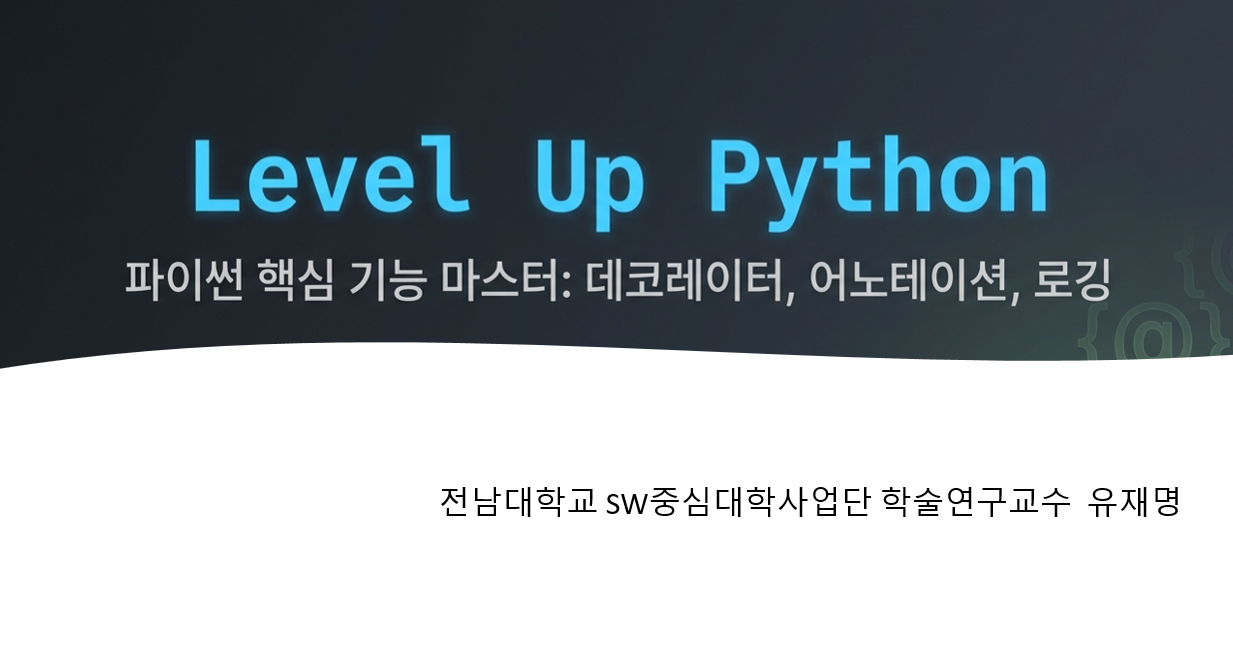

## Python : 어노테이션( Annotation , 타입힌트) 

<img src=attachment:df10e92b-4808-41cc-88b3-a1c061125617.png width=800>  

```python
def 함수이름(매개변수: 타입) -> 반환타입:
    return 반환값
```
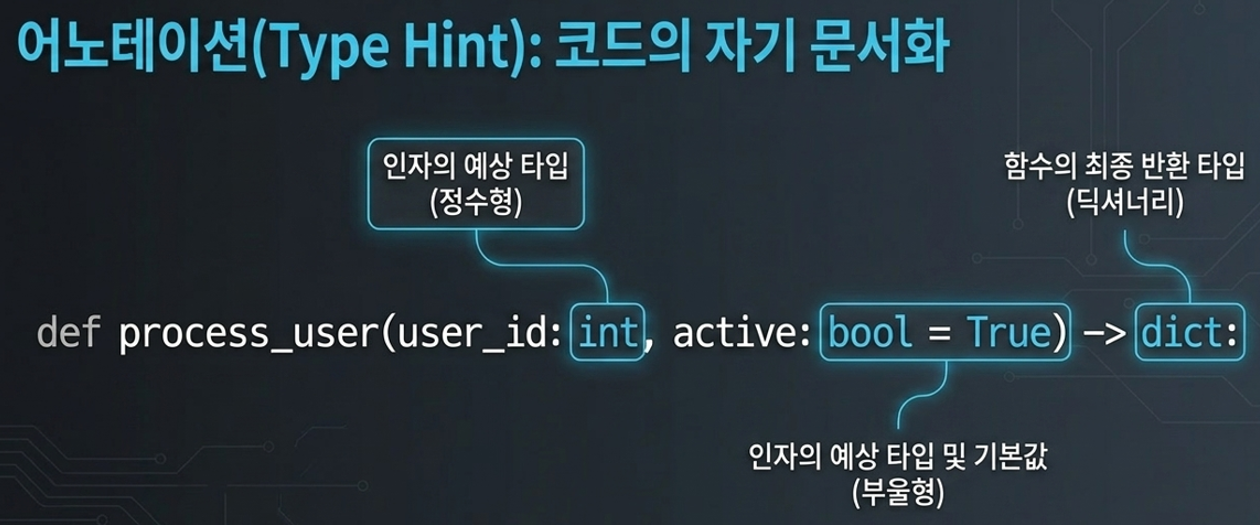

In [5]:
# 1. 함수 매개변수, 반환값 지정
def add(x: int, y: int) -> int:
    return x + y

print("[함수 호출] add(5,7) =", add(5,7))



[함수 호출] add(5,7) = 12


In [10]:
# 2. 변수에 타입 어노테이션 지정
name: str = "Alice"
age: int = 30
is_active: bool = True

print(f"이름: {name}, 나이: {age}, 성격: {'활동적' if is_active else '비활동적'}")



이름: Alice, 나이: 30, 성격: 활동적


In [13]:
# 3. 리스트, 딕셔너리 등에서 사용
from typing import List, Dict

def get_scores() -> List[int]:
    return [90, 80, 70]

def get_user() -> Dict[str, str]:
    return {"name": "홍길동", "city": "서울"}

print(f'get_scores : {get_scores()}')
print(f'get_user : {get_user()}')



get_scores : [90, 80, 70]
get_user : {'name': '홍길동', 'city': '서울'}


In [12]:
# 4. Optional, Union 타입
from typing import Optional, Union

def greet(name: Optional[str] = None) -> str:
    return f"Hello, {name or 'guest'}"

def square(x: Union[int, float]) -> float:
    return x * x

print(greet())
print(greet("Yoo"))
print(f'square(3): {square(3)}')



Hello, guest
Hello, Yoo
square(3): 9


In [16]:
# 5. 함수를 인자로 받는 함수 : Callable
from typing import Callable

def operate(x: int, y: int, func: Callable[[int, int], int]) -> int:
    return func(x, y)

def power(x: int, y: int) -> int:
    return x ** y

print("5 + 3 = ", operate(5, 3, lambda a, b: a + b))  
print("5 ** 3 = ", operate(5, 3, power))



5 + 3 =  8
5 ** 3 =  125


In [17]:
# 5-2. 함수를 인자로 받는 함수 응용
from typing import Callable

def calculator(x: int, y: int, func: Callable[[int, int], int]) -> str:
    result = func(x, y)
    return f"결과: {result}"

operations = {
    "더하기": lambda a, b: a + b,
    "빼기":   lambda a, b: a - b,
    "곱하기": lambda a, b: a * b,
}

for name, op in operations.items():
    print(f"{name} → {calculator(10, 4, op)}")

더하기 → 결과: 14
빼기 → 결과: 6
곱하기 → 결과: 40


## Python : Decorator
- 함수, 메서드, 클래스에 추가 기능을 부여하기 위해

In [3]:
# 1. 실행 시간 측정 데코레이터
import time

def timer(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(f"⏱️ {func.__name__} 함수 실행 시간: {end - start:.4f}초")
        return result
    return wrapper

@timer
def slow_function(t):
    time.sleep(t)
    print("함수 완료!")

slow_function(10)

함수 완료!
⏱️ slow_function 함수 실행 시간: 10.0009초


In [4]:
# 2. 접근 제한 데코레이터(권한 체크)
def require_admin(func):
    def wrapper(user):
        if user != 'admin':
            print("🚫 접근 권한이 없습니다.")
            return
        return func(user)
    return wrapper

@require_admin
def delete_user(user):
    print(f"✅ {user}가 사용자 삭제 기능을 실행합니다.")

delete_user("guest")  # 접근 거부
delete_user("admin")  # 실행됨


🚫 접근 권한이 없습니다.
✅ admin가 사용자 삭제 기능을 실행합니다.


In [5]:
# 3. 결과 캐싱 데코레이터(메모이제이션)
# 메모이제이션(Memoization)은 함수의 실행 결과를 저장하여, 
# 동일한 입력에 대해 재계산하는 대신 저장된 결과를 재사용하여 
# 프로그램의 성능을 최적화하는 기법
cache = {}

def memoize(func):
    def wrapper(n):
        if n in cache:
            print("📦 캐시 사용!")
            return cache[n]
        result = func(n)
        cache[n] = result
        return result
    return wrapper

@memoize
def factorial(n):                                                                       
    if n == 0:
        return 1
    return n * factorial(n - 1)

print(factorial(5))
print(factorial(5))  # 캐시 사용됨


120
📦 캐시 사용!
120


In [6]:
# 4. 로그 출력 데코레이터
def logger(func):
    def wrapper(*args, **kwargs):
        print(f"📘 호출: {func.__name__} with args={args}, kwargs={kwargs}")
        return func(*args, **kwargs)
    return wrapper

@logger
def add(a, b):
    return a + b

add(3, 5)


📘 호출: add with args=(3, 5), kwargs={}


8

In [7]:
# 5. 여러 데코레이터 중첩 사용
# 튜플 형태 *args : func(1,2,3) -> args = (1,2,3)
# 딕셔너리 형태 **kwargs : func(a=10, b=20) -> kwargs = {'a':10, 'b':20}

def bold(func):
    def wrapper(*args, **kwargs):
        return "<b>" + func(*args, **kwargs) + "</b>"
    return wrapper

def italic(func):
    def wrapper(*args, **kwargs):
        return "<i>" + func(*args, **kwargs) + "</i>"
    return wrapper

@bold
@italic
def greet():
    return "Hello!"

print(greet())  # <b><i>Hello!</i></b>

<b><i>Hello!</i></b>


## 로깅(Logging): 코드 실행 중 발생하는 정보를 파일이나 콘솔에 남겨 디버깅, 오류 추적, 이벤트 기록 등에 사용

### 1. logging.basicConfig(...) — 로깅 전역 설정

> 프로그램 전체의 로그 출력 방식을 초기화하는 함수  

```python
#전체코드구조
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s'
)
log = logging.getLogger("MyLog")
```

---  

### level=logging.INFO
> 로그를 어느 수준부터 출력할지 결정하는 설정

```
로그 레벨 (낮음 → 높음)
─────────────────────────────────────────────
DEBUG    (10) : 개발용 세부 정보        ← INFO 설정 시 출력 ❌
INFO     (20) : 일반 정보 메시지        ← 출력 ✅
WARNING  (30) : 경고 (문제 가능성)      ← 출력 ✅
ERROR    (40) : 오류 발생              ← 출력 ✅
CRITICAL (50) : 심각한 오류            ← 출력 ✅
─────────────────────────────────────────────
level=logging.INFO → INFO 이상만 출력
```

In [2]:
# 1. 기본 로깅 설정
import logging

logging.basicConfig(level=logging.INFO)  # basicConfig 로그레벨 : DEBUG < INTO < WARNING < ERROR < CRITICAL 

logging.debug("이건 디버그 메시지")   # 출력되지 않음
logging.info("정보 메시지 출력")        # 출력됨
logging.warning("경고 메시지")         # 출력됨
logging.error("오류 메시지")           # 출력됨


INFO:root:정보 메시지 출력
ERROR:root:오류 메시지


In [28]:
# 2. 로그를 파일로 저장
import logging

logging.basicConfig(
    filename='app.log',
    level=logging.DEBUG,
    encoding='utf-8', #한글 깨지지 않도록 명시할 것
    format='%(asctime)s - %(levelname)s - %(message)s'
)

logging.debug("디버그 로그 저장")
logging.info("정보 로그 저장")
logging.error("에러 로그 저장")


###  format='%(asctime)s [%(levelname)s] %(message)s'
> 로그 메시지의 출력 형식(포멧)을 지정  
> 주요 포멧 변수 정리
<img src=attachment:e363c121-3aff-4a3e-b3c2-7342e9345a15.png>  
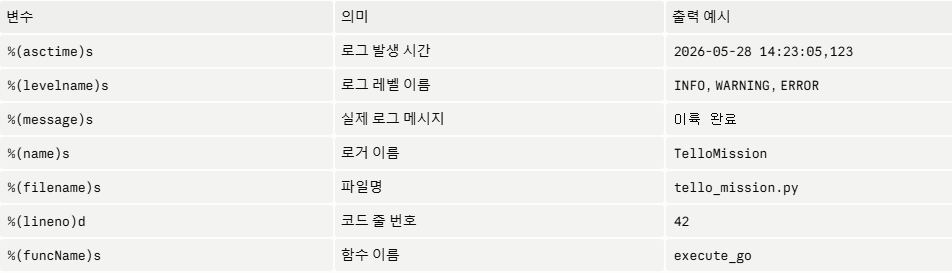

In [4]:
# 로그 파일에 저장이 안될때 사용
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

logging.basicConfig(
    filename='app.log',
    level=logging.DEBUG,
    encoding='utf-8', #한글 깨지지 않도록 명시할 것
    format='%(asctime)s - %(levelname)s - %(message)s'
)
# 이름 없는 로거(기본으로 root logger 사용)
logging.info("정보 로그 저장")

# 이름 있는 로거(권장)
log = logging.getLogger("MyLog")
log.info("My 메시지")

In [9]:
# 로그 파일 결과 확인
with open('app.log', 'r', encoding='utf-8') as f:
    print(f.read())

2026-05-28 17:02:15,653 - INFO - 정보 로그 저장
2026-05-28 17:02:15,653 - INFO - My 메시지



In [3]:
# 예외 처리
import logging

logging.basicConfig(level=logging.INFO)

def divide(a, b):
    try:
        result = a / b
        logging.info(f"{a} / {b} = {result}")
        return result
    except ZeroDivisionError:
        logging.error("0으로 나눌 수 없습니다!")

divide(10, 2)
divide(5, 0)


INFO:root:10 / 2 = 5.0
ERROR:root:0으로 나눌 수 없습니다!
